<a href="https://colab.research.google.com/github/7235SYXD/Real-Estate/blob/main/DSP_Workflow_Diagram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


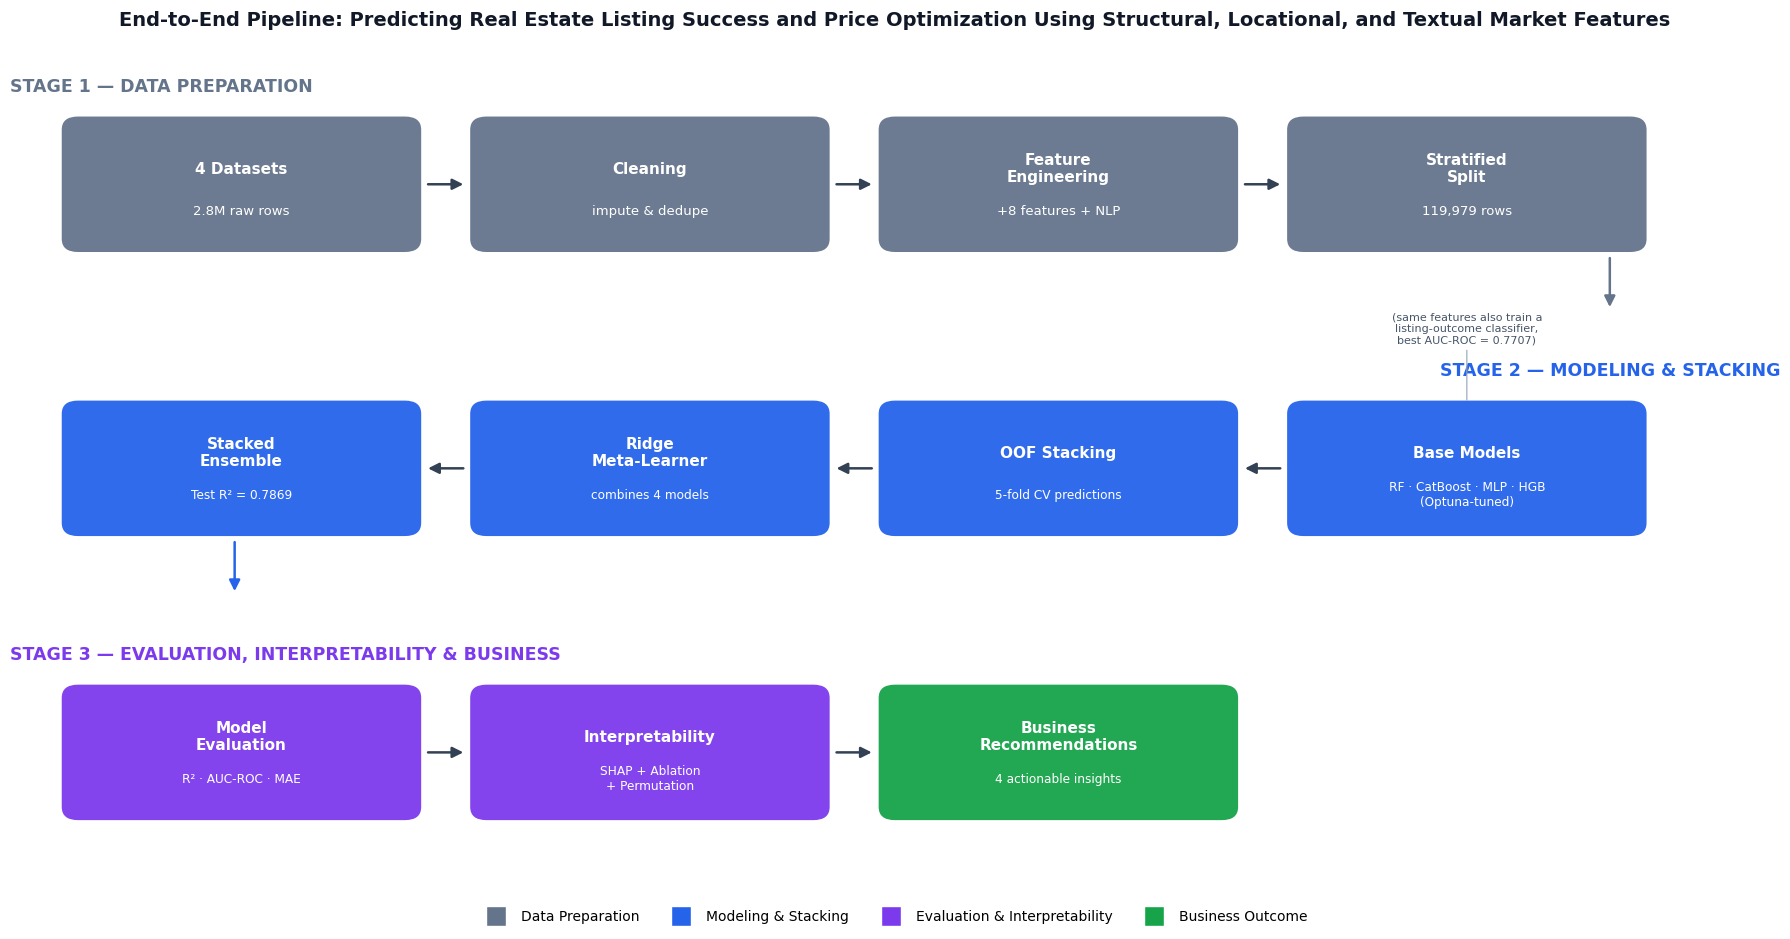

Saved successfully to:
/content/drive/MyDrive/workflow_diagram/pipeline_workflow.png


In [14]:
# =============================================================================
# Project Pipeline Workflow Diagram
# =============================================================================

%matplotlib inline

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D
import os

# =============================================================================
# Saving to Google Drive
# =============================================================================
from google.colab import drive
drive.mount('/content/drive')

# =============================================================================
# Create Figure
# =============================================================================

fig, ax = plt.subplots(figsize=(18 , 9.5 ))
ax.set_xlim(0, 13)
ax.set_ylim(0, 8)
ax.axis("off")

# ── Colors ───────────────────────────────────────────────────────────────────
C_PREP  = "#64748B"
C_MODEL = "#2563EB"
C_EVAL  = "#7C3AED"
C_BIZ   = "#16A34A"
TEXT_C  = "#FFFFFF"

# =============================================================================
# Helper Functions
# =============================================================================

def draw_box(x, y, w, h, title, subtitle, color,
             fontsize_title=11, fontsize_sub=9.5):

    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        linewidth=0,
        facecolor=color,
        alpha=0.95,
        zorder=3
    )

    ax.add_patch(box)

    ax.text(
        x + w/2,
        y + h*0.62,
        title,
        ha="center",
        va="center",
        fontsize=fontsize_title,
        fontweight="bold",
        color=TEXT_C
    )

    ax.text(
        x + w/2,
        y + h*0.30,
        subtitle,
        ha="center",
        va="center",
        fontsize=fontsize_sub,
        color=TEXT_C,
        wrap=True
    )


def h_arrow(x1, y, x2, color="#334155"):
    arr = FancyArrowPatch(
        (x1, y),
        (x2, y),
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=1.8,
        color=color
    )
    ax.add_patch(arr)


def v_arrow(x, y1, y2, color="#334155"):
    arr = FancyArrowPatch(
        (x, y1),
        (x, y2),
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=1.8,
        color=color
    )
    ax.add_patch(arr)

# =============================================================================
# Stage 1, Stage 2, Stage 3 pipeline
# =============================================================================

# ══════════════════════════════════════════════════════════════════════════
# STAGE 1 — DATA PREPARATION
# ══════════════════════════════════════════════════════════════════════════
y1 = 5.8
h1 = 1.2
boxes_1 = [
    (0.4, "4 Datasets", "2.8M raw rows"),
    (3.4, "Cleaning", "impute & dedupe"),
    (6.4, "Feature\nEngineering", "+8 features + NLP"),
    (9.4, "Stratified\nSplit", "119,979 rows"),
]
bw1 = 2.6
for x, title, sub in boxes_1:
    draw_box(x, y1, bw1, h1, title, sub, C_PREP)
for i in range(len(boxes_1)-1):
    x_end = boxes_1[i][0] + bw1
    x_start_next = boxes_1[i+1][0]
    h_arrow(x_end + 0.05, y1 + h1/2, x_start_next - 0.05)

ax.text(0.0, y1 + h1 + 0.25, "STAGE 1 — DATA PREPARATION",
        fontsize=12.5, fontweight="bold", color=C_PREP, ha="left")

# connector down to stage 2
v_arrow(11.75, y1 - 0.05, y1 - 0.55, color=C_PREP)

# ══════════════════════════════════════════════════════════════════════════
# STAGE 2 — MODELING & STACKING
# ══════════════════════════════════════════════════════════════════════════
y2 = 3.2
h2 = 1.2
boxes_2 = [
    (9.4, "Base Models", "RF · CatBoost · MLP · HGB\n(Optuna-tuned)"),
    (6.4, "OOF Stacking", "5-fold CV predictions"),
    (3.4, "Ridge\nMeta-Learner", "combines 4 models"),
    (0.4, "Stacked\nEnsemble", "Test R\u00b2 = 0.7869"),
]
bw2 = 2.6
for x, title, sub in boxes_2:
    draw_box(x, y2, bw2, h2, title, sub, C_MODEL, fontsize_sub=8.7)
for i in range(len(boxes_2)-1):
    x_start = boxes_2[i][0]
    x_end_next = boxes_2[i+1][0] + bw2
    h_arrow(x_start - 0.05, y2 + h2/2, x_end_next + 0.05)

ax.text(13.0, y2 + h2 + 0.25, "STAGE 2 — MODELING & STACKING",
        fontsize=12.5, fontweight="bold", color=C_MODEL, ha="right")

# also branch: base models feed a parallel classifier (shown as small note)
ax.annotate("(same features also train a\nlisting-outcome classifier,\nbest AUC-ROC = 0.7707)",
            xy=(10.7, y2 + h2), xytext=(10.7, y2 + h2 + 0.55),
            fontsize=8, color="#475569", ha="center",
            arrowprops=dict(arrowstyle="-", color="#94A3B8", lw=0.8))

# connector down to stage 3
v_arrow(1.65, y2 - 0.05, y2 - 0.55, color=C_MODEL)

# ══════════════════════════════════════════════════════════════════════════
# STAGE 3 — EVALUATION, INTERPRETABILITY & BUSINESS
# ══════════════════════════════════════════════════════════════════════════
y3 = 0.6
h3 = 1.2
boxes_3 = [
    (0.4, "Model\nEvaluation", "R\u00b2 · AUC-ROC · MAE"),
    (3.4, "Interpretability", "SHAP + Ablation\n+ Permutation"),
    (6.4, "Business\nRecommendations", "4 actionable insights"),
]
bw3 = 2.6
for x, title, sub in boxes_3:
    draw_box(x, y3, bw3, h3, title, sub, C_EVAL if title != "Business\nRecommendations" else C_BIZ,
              fontsize_sub=8.7)
for i in range(len(boxes_3)-1):
    x_end = boxes_3[i][0] + bw3
    x_start_next = boxes_3[i+1][0]
    h_arrow(x_end + 0.05, y3 + h3/2, x_start_next - 0.05)

ax.text(0.0, y3 + h3 + 0.25, "STAGE 3 — EVALUATION, INTERPRETABILITY & BUSINESS",
        fontsize=12.5, fontweight="bold", color=C_EVAL, ha="left")

# ── Title ───────────────────────────────────────────────────────────────────
ax.text(6.5, 7.85,
        "End-to-End Pipeline: Predicting Real Estate Listing Success and Price Optimization Using Structural, Locational, and Textual Market Features",
        fontsize=14, fontweight="bold", ha="center", color="#111827")

# ── Legend ──────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], marker="s", color="w", markerfacecolor=C_PREP, markersize=14, label="Data Preparation"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=C_MODEL, markersize=14, label="Modeling & Stacking"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=C_EVAL, markersize=14, label="Evaluation & Interpretability"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=C_BIZ, markersize=14, label="Business Outcome"),
]
ax.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(0.5, -0.06),
          ncol=4, frameon=False, fontsize=10)

plt.tight_layout()


# =============================================================================
# Save + Display
# =============================================================================

plt.tight_layout()

output_dir = "/content/drive/MyDrive/workflow_diagram"

os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, "pipeline_workflow.png")

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

# Display in notebook
plt.show()

print(f"Saved successfully to:\n{output_file}")